# CYNAR paper 1 -- Fig. 1: illustrating the traffic fit

Purely illustrative figure (not a merit A/B/C result): what `cynar.traffic.estimate_derivatives`
actually does to a measured correlation function $C_*(t)$ to get the traffic $\mathcal{T}$. Three
rows, each shown wide (left column) and enlarged onto the actual fit window (right column):

- **Row 1**: Brownian vortex at $\Phi=0$ (equilibrium), a diagonal element $C^{ii}_*(t)$. With no
  rotational drive, the drift matrix has real eigenvalues, so this is a clean, single-exponential-like
  decay with $C''(0)>0$ -- the "dominant positive concavity" the main text associates with
  $\mathcal{T}<0$, i.e. a case *compatible with* equilibrium (though not exclusive to it).
- **Row 2**: Lorenz-96, a diagonal element $C^{ii}_*(t)$. Same nonzero-slope decay shape as row 1,
  but now $C''(0)<0$ -- the negative-concavity case the main text associates with $\mathcal{T}>0$,
  i.e. a system that is *for sure* out of equilibrium.
- **Row 3**: Lorenz-96, an off-diagonal element $C^{ij}_*(t)$, $i\ne j$, for which $D^{ij}=0$ forces
  $C'(0)=0$ (a flat start) even though $C(0)\ne0$: the curve instead grows away from $C(0)$
  quadratically, governed by $C''(0)\ne0$, before eventually decaying. Since `auto_window`'s
  tolerance test compares $|C(t)|$ against $|C(t_{i_1})|$, not against $t=0$, this lets the fit
  window terminate on the *rising* side, well before the correlation's real peak -- unlike rows 1-2,
  where it can only ever terminate on the decaying side.

Rows 2-3 reuse the same Lorenz-96 trajectory (one diagonal and one off-diagonal element of it).
Neither $H$ nor $i_1$ anywhere below is the value actually used for any real result elsewhere in the
paper -- all are hand-picked only to make a clear illustration.

In [129]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, ".")
import numpy as np
import matplotlib.pyplot as plt

import cynar
from cynar.simul.Lorenz96 import simulate_Lorenz96
from cynar.simul.linear import simulate_linear_diffusion
from cynar.simul.hair import simulate_hair_bundle
from cynar.correl import auto_window, fit_exp_poly_times
from cynar.cfg import ExpPolyCfg

import common as C

np.set_printoptions(precision=4, suppress=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Row 1 data: Brownian vortex at $\Phi=0$ (equilibrium)

Same $\alpha=0.2$, $T_1=T_2=1$ as Sec. II A, but $\Phi=0$: no rotational drive, so the drift matrix
is diagonal with real eigenvalues and the system sits at genuine equilibrium. The diagonal element
$C^{00}_*(t)$ decays very slowly here (rate set by $\alpha=0.2$), so the wide/zoom panels below use
a much longer $t$ range than rows 2-3.

In [134]:
dt_lin = 5e-2
alph, Phi, T1, T2 = 0.2, .0, 1.0, 1.0
A_lin = np.array([[-alph, -Phi], [alph * Phi, -1.0]])
D_lin = np.array([[T1, 0.0], [0.0, T2]])

X_lin = simulate_linear_diffusion(500_000, A_lin, D_lin, dt_lin, oversampling=50, method="heun", seed=12345)

data_diag_eq = C.traffic_fit_illustration_data(
    X_lin, dt_lin, i=0, j=0, i1_window=3, H=0.2, max_lag=500, Ne=1, Ng=1,
)
print(f"diagonal   (i=0,j=0): i1={data_diag_eq['i1']} i2={data_diag_eq['i2']}"
      f"  D={-data_diag_eq['cp']:.4f} (true {D_lin[0,0]:.1f})  C''(0)={data_diag_eq['cpp']:.4f}")

diagonal   (i=0,j=0): i1=3 i2=25  D=0.9895 (true 1.0)  C''(0)=0.1787


## Rows 2-3 data: Lorenz-96, $N=6$

One trajectory gives both: row 2 uses site $0$'s own autocorrelation $C^{00}_*(t)$ (diagonal, all
sites at the same $D^{ii}=D_0$ here), row 3 the (site $0$, site $1$) cross-correlation $C^{01}_*(t)$
(off-diagonal, $D^{01}=0$ exactly since $\mathsf D$ is diagonal).

In [142]:
D0 = 20.0
D = np.diag([D0, D0, D0, D0, D0, D0])
dtt = 2.5e-3

tt, X, divA = simulate_Lorenz96(T_steps=1_000_000, dt=dtt, D=D, F=8.0, scheme="Heun", oversampling=20, seed=123)
t=tt*10
dt=dtt*10

In [139]:
i1=4

data_diag = C.traffic_fit_illustration_data(
    X, dt, i=0, j=0, i1_window=i1, H=0.1, max_lag=500, Ne=1, Ng=1,
)
print(f"diagonal   (i=0,j=0): i1={data_diag['i1']} i2={data_diag['i2']}"
      f"  D={-data_diag['cp']:.4f} (true {D[0,0]:.1f})  C''(0)={data_diag['cpp']:.4f}")

data_offdiag = C.traffic_fit_illustration_data(
    X, dt, i=0, j=1, i1_window=i1, H=0.05, max_lag=500, Ne=1, Ng=2,
)
print(f"off-diag   (i=0,j=1): i1={data_offdiag['i1']} i2={data_offdiag['i2']}"
      f"  D={-data_offdiag['cp']:.4f} (true 0)  C''(0)={data_offdiag['cpp']:.4f}")

# Same off-diagonal window, but with the plain linear polynomial term (Ng=1)
# that already suffices for the diagonal case: too rigid to represent a flat
# start followed by growth, the fit compensates with a spurious nonzero slope.
(cp_ng1, cpp_ng1), _, _ = fit_exp_poly_times(
    data_offdiag["t"][data_offdiag["i1"]:data_offdiag["i2"] + 1],
    data_offdiag["Cs"][data_offdiag["i1"]:data_offdiag["i2"] + 1],
    ExpPolyCfg(Ne=1, Ng=1),
)
print(f"off-diag, but with Ng=1 (too rigid): spurious D={-cp_ng1:.4f} (true 0)  C''(0)={cpp_ng1:.4f}")

diagonal   (i=0,j=0): i1=4 i2=21  D=1.9556 (true 20.0)  C''(0)=-17.6916
off-diag   (i=0,j=1): i1=4 i2=26  D=-0.0080 (true 0)  C''(0)=0.5452
off-diag, but with Ng=1 (too rigid): spurious D=-0.1851 (true 0)  C''(0)=-0.0000


## Composed figure

3x2: row 1 (vortex, equilibrium, $C''>0$), row 2 (Lorenz-96 diagonal, $C''<0$), row 3 (Lorenz-96
off-diagonal, $D^{ij}=0$); columns are (wide context, enlargement onto the fit window). No
osculating parabola (tangent line only), no D/C''(0) inset by default.

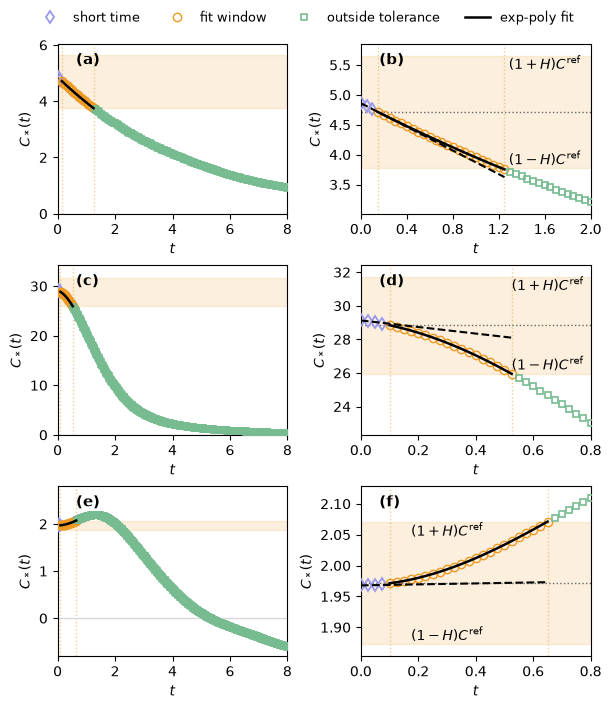

In [172]:
fig, axs = plt.subplots(3, 2, figsize=(6., 7.), constrained_layout=True)

# Row 1: Brownian vortex, Phi=0 (equilibrium), diagonal, C''>0
C.plot_traffic_fit_illustration(
    axs[0, 0], data_diag_eq, panel_label="(a)", t_max=8.0, show_derivatives=False,
)
C.plot_traffic_fit_illustration(
    axs[0, 1], data_diag_eq, panel_label="(b)", t_max=2, annotateC=1.6,
)

# Row 2: Lorenz-96, diagonal, C''<0
C.plot_traffic_fit_illustration(
    axs[1, 0], data_diag, panel_label="(c)", t_max=8, show_derivatives=False,
)
C.plot_traffic_fit_illustration(
    axs[1, 1], data_diag, panel_label="(d)", t_max=.8, annotateC=0.65,
)

# Row 3: Lorenz-96, off-diagonal, D^{ij}=0
C.plot_traffic_fit_illustration(
    axs[2, 0], data_offdiag, panel_label="(e)", t_max=8, show_derivatives=False,
)
C.plot_traffic_fit_illustration(
    axs[2, 1], data_offdiag, panel_label="(f)", t_max=.8, annotateC=0.3,
)

handles, labels = axs[1, 1].get_legend_handles_labels()
fig.legend(handles, labels, loc="outside upper center", ncol=4, fontsize=9, frameon=False)
axs[0,0].set_ylim(0,)
axs[1,0].set_ylim(0,)
axs[2,0].set_ylim(-0.80,2.8)

fig.savefig(str(C.FIGURES_DIR / "traffic_fit_illustration.pdf"), dpi=300, bbox_inches="tight")
plt.show()